---
## 1️⃣ Setup y Configuración Inicial

In [1]:
# Instalación de dependencias (ejecutar si es necesario)
# !pip install pandas numpy scikit-learn sentence-transformers faiss-cpu torch matplotlib seaborn tqdm

In [2]:
# Importaciones principales
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
warnings.filterwarnings('ignore')

# Agregar directorio actual al path para imports
sys.path.append(str(Path.cwd()))

print("✅ Importaciones completadas")

✅ Importaciones completadas


In [3]:
# Importar utilidades del proyecto
from utils import (
    AnimeRecommender,
    load_anime_data,
    preprocess_anime_data,
    create_sample_data,
    load_embedding_model,
    generate_embeddings,
    create_faiss_index,
    get_all_genres,
    parse_genres,
    clean_genre,
    clean_genres_string,
    print_recommendations
)

print("✅ Utilidades del proyecto cargadas")

✅ Utilidades del proyecto cargadas


In [4]:
# Configuración de rutas
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"
EMBEDDINGS_DIR = PROJECT_DIR / "embeddings"

# Crear directorios si no existen
for directory in [DATA_DIR, MODELS_DIR, EMBEDDINGS_DIR]:
    directory.mkdir(exist_ok=True)

print(f"📁 Directorio del proyecto: {PROJECT_DIR}")
print(f"📊 Datos: {DATA_DIR}")
print(f"🤖 Modelos: {MODELS_DIR}")

📁 Directorio del proyecto: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System
📊 Datos: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\data
🤖 Modelos: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\models


---
## 2️⃣ Carga y Exploración de Datos

### Dataset

Usaremos datos de anime con:
- **Título**: Nombre del anime
- **Sinopsis**: Descripción textual (clave para embeddings)
- **Géneros**: Categorías del anime
- **Score**: Rating promedio

**Fuentes de datos recomendadas:**
- [Kaggle: Anime Dataset with Reviews](https://www.kaggle.com/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews)
- [Kaggle: MyAnimeList Dataset](https://www.kaggle.com/datasets/azathoth42/myanimelist)
- [Kaggle: Anime Recommendations Database](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database)

In [5]:
# Opción 1: Cargar desde archivo CSV (descarga el dataset de Kaggle)
# Descomenta y ajusta la ruta si tienes el archivo

# DATA_FILE = DATA_DIR / "anime.csv"  # o "animes.csv" según el dataset
# df_raw = pd.read_csv(DATA_FILE)

# Opción 2: Usar datos de ejemplo para demostración
# (Útil para probar el sistema sin descargar datasets grandes)

USE_SAMPLE_DATA = False  # True: si quieres usar datos de ejemplo - False: si quieres cargar el dataset real

if USE_SAMPLE_DATA:
    print("📦 Usando datos de ejemplo para demostración...")
    df_raw = create_sample_data()
else:
    # Ajusta esta ruta al archivo descargado
    DATA_FILE = DATA_DIR / "animes.csv"
    df_raw = pd.read_csv(DATA_FILE)

print(f"\n📊 Dataset cargado: {len(df_raw)} registros")
df_raw.head()


📊 Dataset cargado: 19311 registros


,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link
0,28891,Haikyuu!! Second Season,"Following their participation at the Inter-High, the Karasuno High School volleyball team attemp...","['Comedy', 'Sports', 'Drama', 'School', 'Shounen']","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/76662.jpg,https://myanimelist.net/anime/28891/Haikyuu_Second_Season
1,23273,Shigatsu wa Kimi no Uso,"Music accompanies the path of the human metronome, the prodigious pianist Kousei Arima. But afte...","['Drama', 'Music', 'Romance', 'School', 'Shounen']","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/67177.jpg,https://myanimelist.net/anime/23273/Shigatsu_wa_Kimi_no_Uso
2,34599,Made in Abyss,"The Abyss—a gaping chasm stretching down into the depths of the earth, filled with mysterious cr...","['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'Fantasy']","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/86733.jpg,https://myanimelist.net/anime/34599/Made_in_Abyss
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, something of equal value must be lost."" \r\n \r\nAlchemy...","['Action', 'Military', 'Adventure', 'Comedy', 'Drama', 'Magic', 'Fantasy', 'Shounen']","Apr 5, 2009 to Jul 4, 2010",64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/96541.jpg,https://myanimelist.net/anime/5114/Fullmetal_Alchemist__Brotherhood
4,31758,Kizumonogatari III: Reiketsu-hen,"After helping revive the legendary vampire Kiss-shot Acerola-orion Heart-under-blade, Koyomi Ara...","['Action', 'Mystery', 'Supernatural', 'Vampire']","Jan 6, 2017",1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/81576.jpg,https://myanimelist.net/anime/31758/Kizumonogatari_III__Reiketsu-hen


In [6]:
# Información del dataset
print("\n📋 Información del Dataset")
print("=" * 50)
print(f"Registros: {len(df_raw):,}")
print(f"Columnas: {len(df_raw.columns)}")
print(f"\nColumnas disponibles:")
for col in df_raw.columns:
    null_pct = df_raw[col].isnull().mean() * 100
    print(f"  • {col}: {df_raw[col].dtype} ({null_pct:.1f}% nulos)")


📋 Información del Dataset
Registros: 19,311
Columnas: 12

Columnas disponibles:
  • uid: int64 (0.0% nulos)
  • title: object (0.0% nulos)
  • synopsis: object (5.0% nulos)
  • genre: object (0.0% nulos)
  • aired: object (0.0% nulos)
  • episodes: float64 (3.7% nulos)
  • members: int64 (0.0% nulos)
  • popularity: int64 (0.0% nulos)
  • ranked: float64 (16.6% nulos)
  • score: float64 (3.0% nulos)
  • img_url: object (0.9% nulos)
  • link: object (0.0% nulos)


In [7]:
# Preprocesar datos
df = preprocess_anime_data(df_raw)

print(f"\n✅ Datos preprocesados: {len(df)} registros válidos")
print(f"\nColumnas finales: {list(df.columns)}")
df.head()

2025-12-26 12:28:09,644 - INFO - Preprocesando datos de anime...
2025-12-26 12:28:11,434 - INFO - Datos preprocesados: 19311 registros válidos



✅ Datos preprocesados: 19311 registros válidos

Columnas finales: ['anime_id', 'title', 'synopsis', 'genres', 'aired', 'episodes', 'members', 'popularity', 'ranked', 'score', 'img_url', 'link', 'combined_text']


,anime_id,title,synopsis,genres,aired,episodes,members,popularity,ranked,score,img_url,link,combined_text
0,28891,Haikyuu!! Second Season,"Following their participation at the Inter-High, the Karasuno High School volleyball team attemp...","Comedy, Sports, Drama, School, Shounen","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/76662.jpg,https://myanimelist.net/anime/28891/Haikyuu_Second_Season,"Title: Haikyuu!! Second Season | Genres: Comedy, Sports, Drama, School, Shounen | Synopsis: Foll..."
1,23273,Shigatsu wa Kimi no Uso,"Music accompanies the path of the human metronome, the prodigious pianist Kousei Arima. But afte...","Drama, Music, Romance, School, Shounen","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/67177.jpg,https://myanimelist.net/anime/23273/Shigatsu_wa_Kimi_no_Uso,"Title: Shigatsu wa Kimi no Uso | Genres: Drama, Music, Romance, School, Shounen | Synopsis: Musi..."
2,34599,Made in Abyss,"The Abyss—a gaping chasm stretching down into the depths of the earth, filled with mysterious cr...","Sci-Fi, Adventure, Mystery, Drama, Fantasy","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/86733.jpg,https://myanimelist.net/anime/34599/Made_in_Abyss,"Title: Made in Abyss | Genres: Sci-Fi, Adventure, Mystery, Drama, Fantasy | Synopsis: The Abyss—..."
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, something of equal value must be lost."" \r\n \r\nAlchemy...","Action, Military, Adventure, Comedy, Drama, Magic, Fantasy, Shounen","Apr 5, 2009 to Jul 4, 2010",64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/96541.jpg,https://myanimelist.net/anime/5114/Fullmetal_Alchemist__Brotherhood,"Title: Fullmetal Alchemist: Brotherhood | Genres: Action, Military, Adventure, Comedy, Drama, Ma..."
4,31758,Kizumonogatari III: Reiketsu-hen,"After helping revive the legendary vampire Kiss-shot Acerola-orion Heart-under-blade, Koyomi Ara...","Action, Mystery, Supernatural, Vampire","Jan 6, 2017",1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/81576.jpg,https://myanimelist.net/anime/31758/Kizumonogatari_III__Reiketsu-hen,"Title: Kizumonogatari III: Reiketsu-hen | Genres: Action, Mystery, Supernatural, Vampire | Synop..."


In [8]:
# Explorar texto combinado (usado para embeddings)
print("\n📝 Ejemplo de texto combinado para embeddings:")
print("=" * 60)
for i in range(min(3, len(df))):
    print(f"\n[{i+1}] {df.iloc[i]['title']}")
    print("-" * 40)
    print(df.iloc[i]['combined_text'][:300] + "..." if len(df.iloc[i]['combined_text']) > 300 else df.iloc[i]['combined_text'])


📝 Ejemplo de texto combinado para embeddings:

[1] Haikyuu!! Second Season
----------------------------------------
Title: Haikyuu!! Second Season | Genres: Comedy, Sports, Drama, School, Shounen | Synopsis: Following their participation at the Inter-High, the Karasuno High School volleyball team attempts to refocus their efforts, aiming to conquer the Spring tournament instead.  
 
When they receive an invitat...

[2] Shigatsu wa Kimi no Uso
----------------------------------------
Title: Shigatsu wa Kimi no Uso | Genres: Drama, Music, Romance, School, Shounen | Synopsis: Music accompanies the path of the human metronome, the prodigious pianist Kousei Arima. But after the passing of his mother, Saki Arima, Kousei falls into a downward spiral, rendering him unable to hear the s...

[3] Made in Abyss
----------------------------------------
Title: Made in Abyss | Genres: Sci-Fi, Adventure, Mystery, Drama, Fantasy | Synopsis: The Abyss—a gaping chasm stretching down into the depths of t

---
## 3️⃣ Análisis Exploratorio (EDA)

In [9]:
# Estadísticas descriptivas
if 'score' in df.columns:
    print("\n📊 Estadísticas de Scores/Ratings")
    print(df['score'].describe())


📊 Estadísticas de Scores/Ratings
count    19311.000000
mean         6.243133
std          1.479967
min          0.000000
25%          5.690000
50%          6.370000
75%          7.120000
max          9.230000
Name: score, dtype: float64


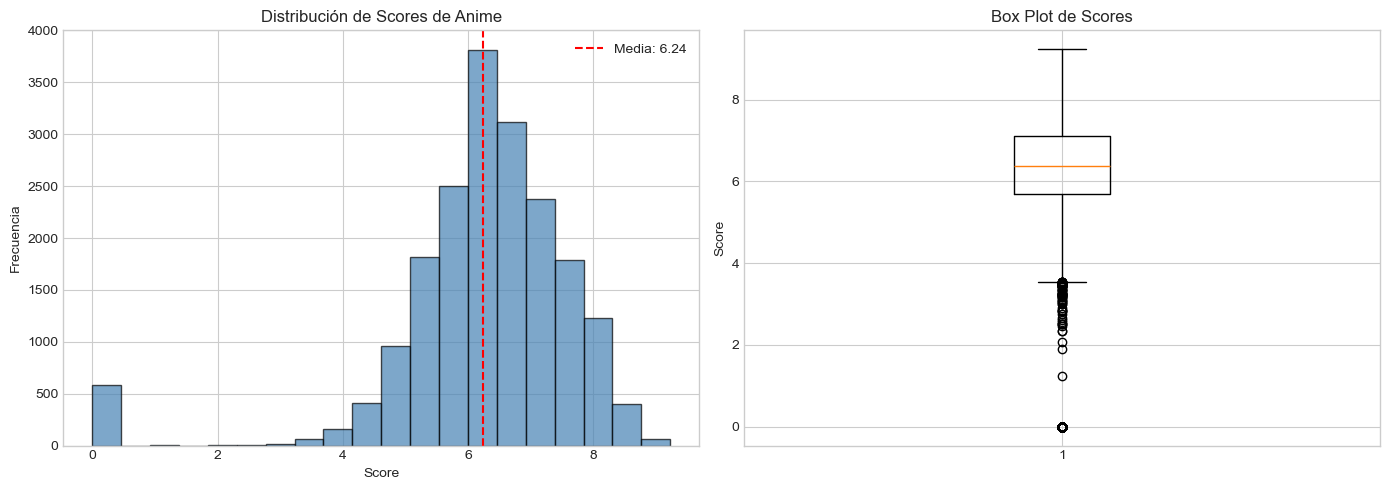

In [10]:
# Distribución de scores
if 'score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma de scores
    axes[0].hist(df['score'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución de Scores de Anime')
    axes[0].axvline(df['score'].mean(), color='red', linestyle='--', label=f'Media: {df["score"].mean():.2f}')
    axes[0].legend()
    
    # Box plot
    axes[1].boxplot(df['score'].dropna(), vert=True)
    axes[1].set_ylabel('Score')
    axes[1].set_title('Box Plot de Scores')
    
    plt.tight_layout()
    plt.show()

In [11]:
# Análisis de géneros
all_genres = get_all_genres(df)
print(f"\n🎭 Géneros únicos encontrados: {len(all_genres)}")
print(all_genres[:20])  # Mostrar primeros 20


🎭 Géneros únicos encontrados: 43
['Action', 'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi', 'Fantasy', 'Game', 'Harem', 'Hentai', 'Historical', 'Horror', 'Josei', 'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military']


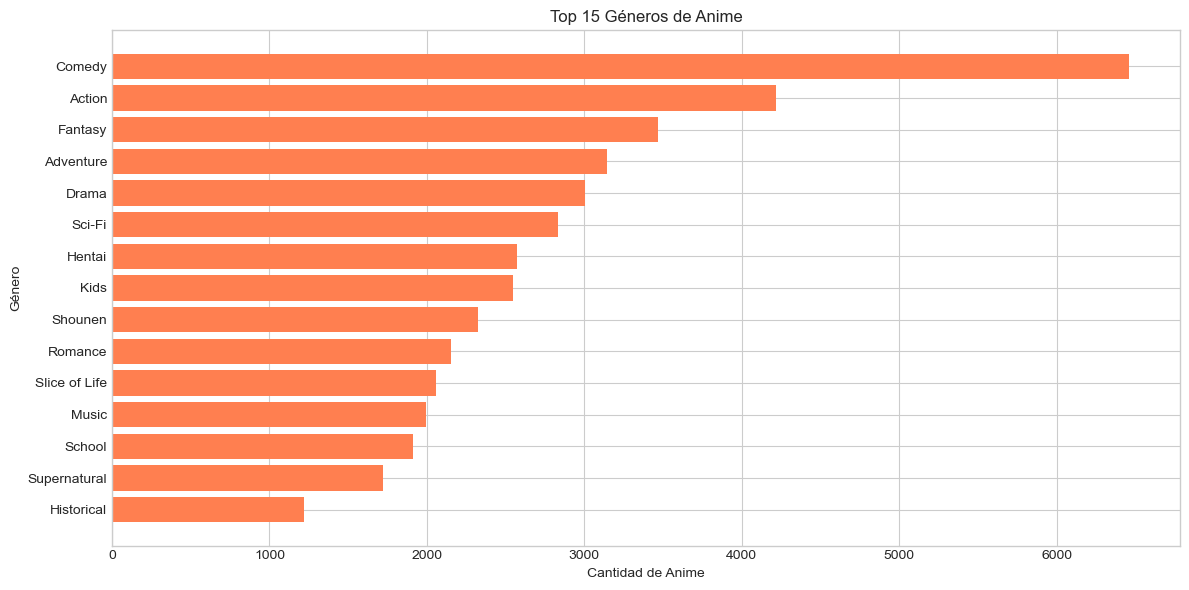

In [12]:
# Contar frecuencia de géneros
genre_counts = {}
for genres_str in df['genres']:
    for genre in parse_genres(genres_str):
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_df = pd.DataFrame([
    {'genre': k, 'count': v} for k, v in genre_counts.items()
]).sort_values('count', ascending=False)

# Visualizar top géneros
if len(genre_df) > 0:
    plt.figure(figsize=(12, 6))
    top_genres = genre_df.head(15)
    plt.barh(top_genres['genre'], top_genres['count'], color='coral')
    plt.xlabel('Cantidad de Anime')
    plt.ylabel('Género')
    plt.title('Top 15 Géneros de Anime')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


📏 Longitud de sinopsis:
count    19311.000000
mean       393.486044
std        354.395705
min          0.000000
25%         94.000000
50%        299.000000
75%        600.000000
max       2753.000000
Name: synopsis_length, dtype: float64


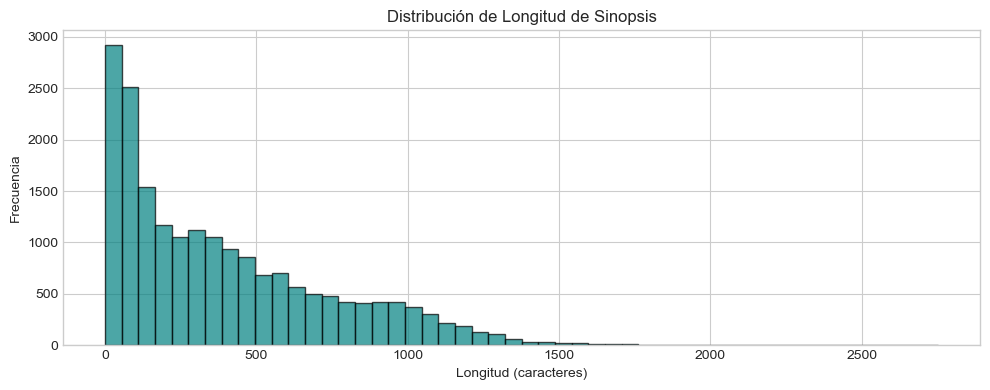

In [13]:
# Longitud de sinopsis
df['synopsis_length'] = df['synopsis'].str.len()

print("\n📏 Longitud de sinopsis:")
print(df['synopsis_length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['synopsis_length'], bins=50, edgecolor='black', alpha=0.7, color='teal')
plt.xlabel('Longitud (caracteres)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Longitud de Sinopsis')
plt.tight_layout()
plt.show()

---
## 4️⃣ Generación de Embeddings

### Modelo: Sentence Transformers

Utilizamos `sentence-transformers/all-MiniLM-L6-v2`:
- **Dimensión**: 384
- **Velocidad**: Rápido y eficiente
- **Calidad**: Excelente para búsqueda semántica

El texto combinado (título + géneros + sinopsis) se convierte en un vector denso que captura el significado semántico.

In [14]:
# Cargar modelo de embeddings
print("🤖 Cargando modelo de Sentence Transformers...")
model = load_embedding_model("sentence-transformers/all-MiniLM-L6-v2")

print(f"\n✅ Modelo cargado")
print(f"   Dimensión de embeddings: {model.get_sentence_embedding_dimension()}")

2025-12-26 12:28:12,830 - INFO - Cargando modelo de embeddings: sentence-transformers/all-MiniLM-L6-v2
2025-12-26 12:28:12,839 - INFO - Use pytorch device_name: cpu
2025-12-26 12:28:12,840 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


🤖 Cargando modelo de Sentence Transformers...


2025-12-26 12:28:13,882 - INFO - Modelo cargado. Dimensión de embeddings: 384



✅ Modelo cargado
   Dimensión de embeddings: 384


In [15]:
# Generar embeddings para todos los anime
texts = df['combined_text'].tolist()
print(f"\n🔄 Generando embeddings para {len(texts)} textos...")

embeddings = generate_embeddings(texts, model, batch_size=32)

print(f"\n✅ Embeddings generados: {embeddings.shape}")
print(f"   Shape: (n_anime, embedding_dim) = {embeddings.shape}")

2025-12-26 12:28:13,905 - INFO - Generando embeddings para 19311 textos...



🔄 Generando embeddings para 19311 textos...


Batches:   0%|          | 0/604 [00:00<?, ?it/s]

2025-12-26 12:32:06,775 - INFO - Embeddings generados: shape (19311, 384)



✅ Embeddings generados: (19311, 384)
   Shape: (n_anime, embedding_dim) = (19311, 384)


In [16]:
# Visualizar embeddings con reducción de dimensionalidad (opcional)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Usar PCA para reducir a 2D (más rápido que t-SNE)
print("\n📉 Reduciendo dimensionalidad para visualización...")
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print(f"   Varianza explicada: {sum(pca.explained_variance_ratio_)*100:.1f}%")


📉 Reduciendo dimensionalidad para visualización...
   Varianza explicada: 7.1%


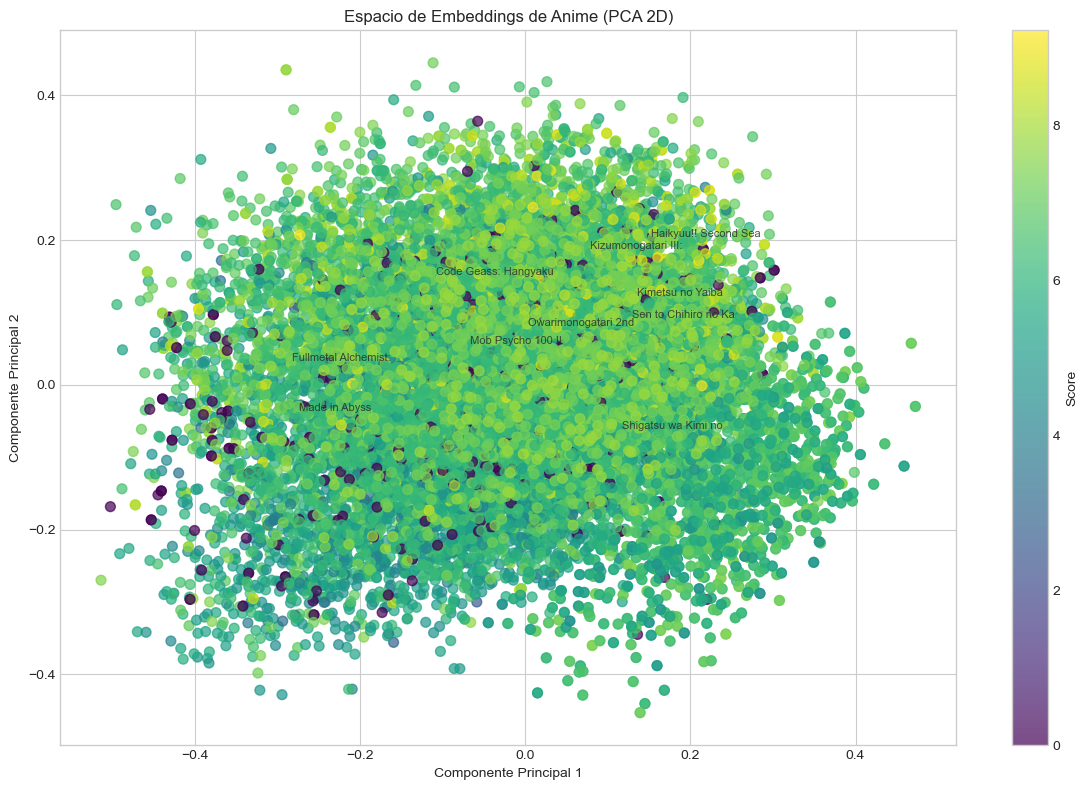

In [17]:
# Visualizar espacio de embeddings
plt.figure(figsize=(12, 8))

# Color por score si está disponible
if 'score' in df.columns:
    scatter = plt.scatter(
        embeddings_2d[:, 0], 
        embeddings_2d[:, 1],
        c=df['score'],
        cmap='viridis',
        alpha=0.7,
        s=50
    )
    plt.colorbar(scatter, label='Score')
else:
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=50)

# Agregar etiquetas para algunos puntos
for i in range(min(10, len(df))):
    plt.annotate(
        df.iloc[i]['title'][:20],
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Espacio de Embeddings de Anime (PCA 2D)')
plt.tight_layout()
plt.show()

---
## 5️⃣ Construcción del Índice Faiss

### ¿Por qué Faiss?

- **Velocidad**: Búsqueda de similaridad en milisegundos
- **Escalabilidad**: Maneja millones de vectores
- **Tipos de índice**:
  - `Flat`: Exacto, mejor para datasets pequeños
  - `IVF`: Aproximado, mejor para datasets grandes
  - `HNSW`: Balance velocidad/precisión

In [18]:
import faiss

# Crear índice Faiss
print("🔍 Creando índice Faiss...")
index = create_faiss_index(embeddings, index_type="flat")

print(f"\n✅ Índice creado")
print(f"   Vectores indexados: {index.ntotal}")
print(f"   Dimensión: {index.d}")

2025-12-26 12:32:07,943 - INFO - Creando índice Faiss (flat) para 19311 vectores de dim 384
2025-12-26 12:32:07,977 - INFO - Índice creado con 19311 vectores


🔍 Creando índice Faiss...

✅ Índice creado
   Vectores indexados: 19311
   Dimensión: 384


In [19]:
# Prueba de búsqueda
print("\n🧪 Prueba de búsqueda vectorial:")

# Buscar los 5 más similares al primer anime
query_vector = embeddings[0:1].astype(np.float32)
k = 5

distances, indices = index.search(query_vector, k)

print(f"\nBuscando similares a: {df.iloc[0]['title']}")
print("-" * 50)
for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    print(f"  {i+1}. {df.iloc[idx]['title']} (similaridad: {dist:.4f})")


🧪 Prueba de búsqueda vectorial:

Buscando similares a: Haikyuu!! Second Season
--------------------------------------------------
  1. Haikyuu!! Second Season (similaridad: 1.0000)
  2. Haikyuu!! Second Season (similaridad: 1.0000)
  3. Haikyuu!!: To the Top 2nd Season (similaridad: 0.8634)
  4. Haikyuu!!: To the Top 2nd Season (similaridad: 0.8634)
  5. Haikyuu!! (similaridad: 0.8605)


---
## 6️⃣ Sistema de Recomendación

### Tipos de Recomendación Implementados:

1. **Por texto**: Describe lo que buscas y obtén recomendaciones
2. **Por anime similar**: "Si te gustó X, te gustará..."
3. **Híbrido**: Combina similaridad semántica + filtros + ratings

In [20]:
# Inicializar sistema de recomendación completo
recommender = AnimeRecommender()

# Configurar con los datos ya procesados
recommender.model = model
recommender.index = index
recommender.df = df
recommender.embeddings = embeddings
recommender._is_initialized = True

print("✅ Sistema de recomendación inicializado")

✅ Sistema de recomendación inicializado


In [21]:
# Recomendación por descripción textual
query = "I want an exciting action anime with supernatural powers and intense battles"

print(f"\n🔎 Búsqueda: '{query}'")
print("=" * 60)

recommendations = recommender.recommend_by_text(query, k=5)
print_recommendations(recommendations, "Resultados")


🔎 Búsqueda: 'I want an exciting action anime with supernatural powers and intense battles'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🎬 Resultados

#1 📺 Shaman King
   Géneros: Action, Adventure, Comedy, Supernatural, Drama, Shounen
   Rating: 7.8/10
   Similaridad: 0.564

#2 📺 Shaman King
   Géneros: Action, Adventure, Comedy, Supernatural, Drama, Shounen
   Rating: 7.8/10
   Similaridad: 0.564

#3 📺 Supernatural The Animation
   Géneros: Action, Demons, Horror, Supernatural
   Rating: 7.1/10
   Similaridad: 0.581

#4 📺 Spectral Force Chronicle Divergence
   Géneros: Fantasy
   Rating: 5.0/10
   Similaridad: 0.624

#5 📺 Ao no Exorcist: Ura Ex
   Géneros: Action, Fantasy, Supernatural, Shounen
   Rating: 7.2/10
   Similaridad: 0.552



In [22]:
# Otra búsqueda: Anime de misterio psicológico
query2 = "A psychological thriller with mystery, mind games, and smart protagonist"

print(f"\n🔎 Búsqueda: '{query2}'")
print("=" * 60)

recommendations2 = recommender.recommend_by_text(query2, k=5)
print_recommendations(recommendations2, "Resultados")


🔎 Búsqueda: 'A psychological thriller with mystery, mind games, and smart protagonist'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🎬 Resultados

#1 📺 Interlude
   Géneros: Adventure, Horror, Mystery
   Rating: 6.5/10
   Similaridad: 0.522

#2 📺 Psycho-Pass 2
   Géneros: Action, Sci-Fi, Police, Psychological
   Rating: 7.5/10
   Similaridad: 0.489

#3 📺 Another
   Géneros: Mystery, Horror, Supernatural, Thriller, School
   Rating: 7.7/10
   Similaridad: 0.469

#4 📺 Psycho-Pass 3
   Géneros: Action, Police, Psychological, Sci-Fi
   Rating: 7.7/10
   Similaridad: 0.459

#5 📺 Fantastic Children
   Géneros: Adventure, Fantasy, Mystery, Romance, Sci-Fi, Thriller
   Rating: 7.6/10
   Similaridad: 0.457



In [23]:
# Recomendación por anime similar
anime_idx = 0  # Índice del anime base
base_anime = df.iloc[anime_idx]

print(f"\n🎬 Anime base: {base_anime['title']}")
print(f"   Géneros: {base_anime['genres']}")
print("=" * 60)

similar = recommender.recommend_similar(anime_idx, k=5)
print_recommendations(similar, f"Similares a '{base_anime['title']}'")


🎬 Anime base: Haikyuu!! Second Season
   Géneros: Comedy, Sports, Drama, School, Shounen

🎬 Similares a 'Haikyuu!! Second Season'

#1 📺 Haikyuu!! Second Season
   Géneros: Comedy, Sports, Drama, School, Shounen
   Rating: 8.8/10
   Similaridad: 1.000

#2 📺 Haikyuu!!: To the Top 2nd Season
   Géneros: Comedy, Drama, School, Shounen, Sports
   Rating: 0.0/10
   Similaridad: 0.863

#3 📺 Haikyuu!!: To the Top 2nd Season
   Géneros: Comedy, Drama, School, Shounen, Sports
   Rating: 0.0/10
   Similaridad: 0.863

#4 📺 Haikyuu!!
   Géneros: Comedy, Sports, Drama, School, Shounen
   Rating: 8.6/10
   Similaridad: 0.860

#5 📺 Haikyuu!!
   Géneros: Comedy, Sports, Drama, School, Shounen
   Rating: 8.6/10
   Similaridad: 0.860



In [24]:
# Recomendación híbrida con filtros
query3 = "Adventure fantasy with magic"
genres_filter = ["Fantasy", "Adventure"]

print(f"\n🔎 Búsqueda híbrida: '{query3}'")
print(f"   Filtro de géneros: {genres_filter}")
print(f"   Score mínimo: 8.0")
print("=" * 60)

hybrid_recs = recommender.recommend_by_text(
    query3,
    k=5,
    genres=genres_filter,
    min_score=8.0,
    hybrid=True
)
print_recommendations(hybrid_recs, "Recomendaciones Híbridas")


🔎 Búsqueda híbrida: 'Adventure fantasy with magic'
   Filtro de géneros: ['Fantasy', 'Adventure']
   Score mínimo: 8.0


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🎬 Recomendaciones Híbridas

#1 📺 Magi: The Kingdom of Magic
   Géneros: Action, Adventure, Magic, Fantasy, Shounen
   Rating: 8.4/10
   Similaridad: 0.570

#2 📺 Magi: The Kingdom of Magic
   Géneros: Action, Adventure, Magic, Fantasy, Shounen
   Rating: 8.4/10
   Similaridad: 0.570

#3 📺 Magi: The Labyrinth of Magic
   Géneros: Action, Adventure, Fantasy, Magic, Shounen
   Rating: 8.2/10
   Similaridad: 0.538

#4 📺 Magi: The Labyrinth of Magic
   Géneros: Action, Adventure, Fantasy, Magic, Shounen
   Rating: 8.2/10
   Similaridad: 0.538



---
## 7️⃣ Evaluación del Sistema

### Métricas de Evaluación:

- **Relevancia semántica**: ¿Las recomendaciones son coherentes con la query?
- **Diversidad**: ¿Hay variedad en los resultados?
- **Cobertura de géneros**: ¿Se respetan los filtros?

In [25]:
# Análisis de similitud promedio
def analyze_recommendations(df_recs):
    """Analiza las recomendaciones obtenidas."""
    print("\n📊 Análisis de Recomendaciones")
    print("-" * 40)
    
    if 'similarity_score' in df_recs.columns:
        print(f"Similaridad promedio: {df_recs['similarity_score'].mean():.4f}")
        print(f"Similaridad min: {df_recs['similarity_score'].min():.4f}")
        print(f"Similaridad max: {df_recs['similarity_score'].max():.4f}")
    
    if 'score' in df_recs.columns:
        print(f"\nRating promedio: {df_recs['score'].mean():.2f}")
    
    # Géneros únicos en resultados
    all_rec_genres = set()
    for genres in df_recs['genres']:
        all_rec_genres.update(parse_genres(genres))
    print(f"\nGéneros cubiertos: {len(all_rec_genres)}")
    print(f"Géneros: {', '.join(list(all_rec_genres)[:10])}")

# Analizar últimas recomendaciones
if len(recommendations) > 0:
    analyze_recommendations(recommendations)


📊 Análisis de Recomendaciones
----------------------------------------
Similaridad promedio: 0.5770
Similaridad min: 0.5516
Similaridad max: 0.6242

Rating promedio: 6.97

Géneros cubiertos: 9
Géneros: Drama, Shounen, Adventure, Comedy, Fantasy, Horror, Action, Demons, Supernatural


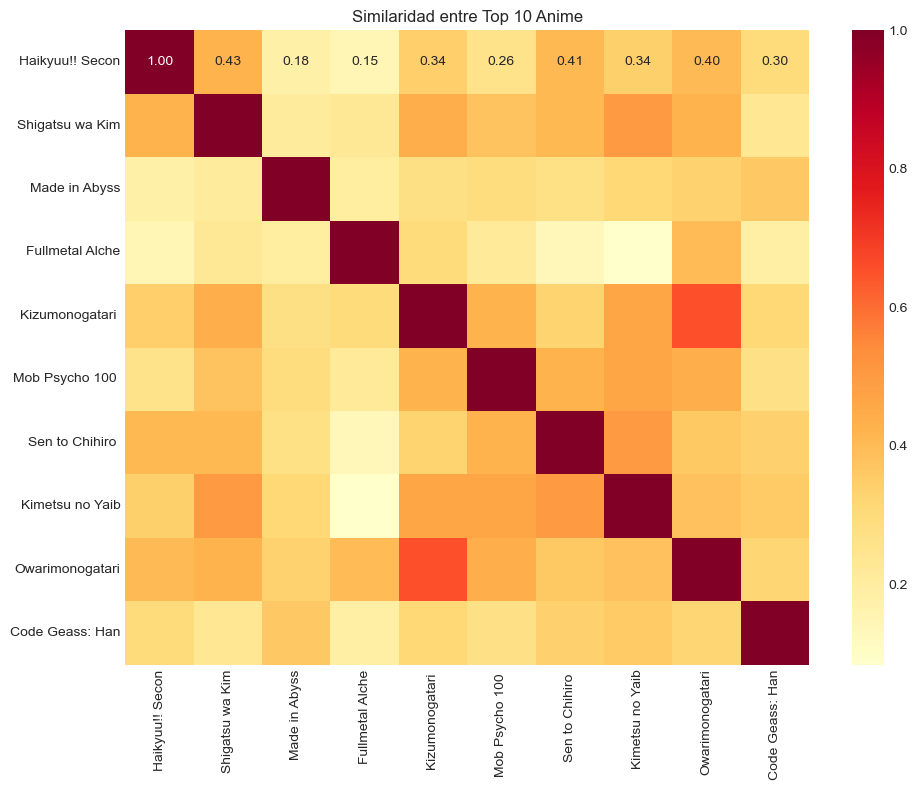

In [26]:
# Matriz de similaridad para los top resultados
def plot_similarity_matrix(df_recs, embeddings, title="Matriz de Similaridad"):
    """Visualiza la matriz de similaridad entre recomendaciones."""
    if len(df_recs) == 0:
        print("No hay recomendaciones para visualizar")
        return
    
    # Obtener índices de las recomendaciones
    indices = df_recs.index.tolist()[:10]
    
    # Calcular matriz de similaridad
    rec_embeddings = embeddings[indices]
    similarity_matrix = np.inner(rec_embeddings, rec_embeddings)
    
    # Visualizar
    plt.figure(figsize=(10, 8))
    labels = [df.iloc[i]['title'][:15] for i in indices]
    
    sns.heatmap(
        similarity_matrix,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd'
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Visualizar matriz de similaridad
plot_similarity_matrix(df.head(10), embeddings, "Similaridad entre Top 10 Anime")

---
## 8️⃣ Guardar Modelo y Artefactos

In [27]:
# Guardar el sistema completo
SAVE_DIR = MODELS_DIR / "anime_recommender"

print(f"💾 Guardando sistema en {SAVE_DIR}...")
recommender.save(SAVE_DIR)

print("\n✅ Archivos guardados:")
for f in SAVE_DIR.iterdir():
    print(f"   • {f.name} ({f.stat().st_size / 1024:.1f} KB)")

2025-12-26 12:35:28,040 - INFO - Embeddings guardados en c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\models\anime_recommender\embeddings.npy
2025-12-26 12:35:28,070 - INFO - Índice Faiss guardado en c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\models\anime_recommender\faiss.index
2025-12-26 12:35:28,137 - INFO - Recomendador guardado en c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\models\anime_recommender


💾 Guardando sistema en c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\models\anime_recommender...

✅ Archivos guardados:
   • anime_data.pkl (17273.2 KB)
   • config.pkl (0.1 KB)
   • embeddings.npy (28966.6 KB)
   • faiss.index (28966.5 KB)


In [28]:
# Verificar que se puede cargar
print("\n🔄 Verificando carga del modelo guardado...")

recommender_loaded = AnimeRecommender()
recommender_loaded.load(SAVE_DIR)

# Probar
test_query = "Action anime with robots"
test_recs = recommender_loaded.recommend_by_text(test_query, k=3)

print(f"\n✅ Modelo cargado correctamente")
print(f"   Test query: '{test_query}'")
print(f"   Resultados: {len(test_recs)} recomendaciones")

2025-12-26 12:35:31,016 - INFO - Cargando modelo de embeddings: sentence-transformers/all-MiniLM-L6-v2
2025-12-26 12:35:31,022 - INFO - Use pytorch device_name: cpu
2025-12-26 12:35:31,023 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2



🔄 Verificando carga del modelo guardado...


2025-12-26 12:35:31,524 - INFO - Modelo cargado. Dimensión de embeddings: 384
2025-12-26 12:35:31,559 - INFO - Embeddings cargados: shape (19311, 384)
2025-12-26 12:35:31,596 - INFO - Índice Faiss cargado: 19311 vectores
2025-12-26 12:35:31,647 - INFO - Recomendador cargado desde c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\03_Anime_Recommender_System\models\anime_recommender


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Modelo cargado correctamente
   Test query: 'Action anime with robots'
   Resultados: 3 recomendaciones


---
## 9️⃣ Demostración Interactiva

In [29]:
def interactive_demo():
    """Demo interactiva del sistema de recomendación."""
    print("\n" + "=" * 60)
    print("🎬 ANIME RECOMMENDER - DEMO INTERACTIVA")
    print("=" * 60)
    
    # Géneros disponibles
    genres = recommender.get_genres()
    print(f"\n🎭 Géneros disponibles ({len(genres)}):")
    print(", ".join(genres[:15]))
    
    # Ejemplos de búsqueda
    queries = [
        "Epic fantasy adventure with magic and dragons",
        "Romantic comedy in high school",
        "Dark psychological thriller with plot twists",
        "Sports anime about teamwork and competition"
    ]
    
    print("\n\n📝 Ejemplos de búsqueda:")
    for i, q in enumerate(queries, 1):
        print(f"  {i}. {q}")
    
    # Ejecutar una búsqueda de ejemplo
    selected_query = queries[0]
    print(f"\n\n🔍 Ejecutando: '{selected_query}'")
    results = recommender.recommend_by_text(selected_query, k=5)
    print_recommendations(results)

# Ejecutar demo
interactive_demo()


🎬 ANIME RECOMMENDER - DEMO INTERACTIVA

🎭 Géneros disponibles (43):
Action, Adventure, Cars, Comedy, Dementia, Demons, Drama, Ecchi, Fantasy, Game, Harem, Hentai, Historical, Horror, Josei


📝 Ejemplos de búsqueda:
  1. Epic fantasy adventure with magic and dragons
  2. Romantic comedy in high school
  3. Dark psychological thriller with plot twists
  4. Sports anime about teamwork and competition


🔍 Ejecutando: 'Epic fantasy adventure with magic and dragons'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


🎬 Recomendaciones

#1 📺 Dragon Quest: Your Story
   Géneros: Adventure, Comedy, Demons, Magic, Martial Arts, Fantasy
   Rating: 6.6/10
   Similaridad: 0.603

#2 📺 Dragon Collection
   Géneros: Fantasy, Shounen
   Rating: 6.3/10
   Similaridad: 0.581

#3 📺 Tian Yu
   Géneros: Action, Adventure, Demons, Fantasy, Magic
   Rating: 6.6/10
   Similaridad: 0.569

#4 📺 Fortune Quest: Yo ni mo Shiawase na Boukensha-tachi
   Géneros: Adventure, Comedy, Fantasy, Magic
   Rating: 6.2/10
   Similaridad: 0.571

#5 📺 Dragon Knight 4
   Géneros: Adventure, Fantasy, Hentai, Magic
   Rating: 5.8/10
   Similaridad: 0.584



---
## 🎯 Resumen y Conclusiones

### Lo que construimos:

1. **Pipeline de datos**: Carga, limpieza y preprocesamiento de datos de anime
2. **Embeddings semánticos**: Usando Sentence Transformers para capturar significado
3. **Índice vectorial**: Faiss para búsqueda eficiente de similaridad
4. **Sistema de recomendación**: 
   - Por descripción textual
   - Por anime similar
   - Híbrido con filtros

### Próximos pasos:

- [ ] Implementar API REST con FastAPI
- [ ] Agregar interfaz web simple
- [ ] Entrenar modelo específico para anime
- [ ] Implementar collaborative filtering adicional

### Tecnologías demostradas:

- **NLP/ML**: Sentence Transformers, embeddings semánticos
- **Búsqueda vectorial**: Faiss, similaridad coseno
- **Python**: Pandas, NumPy, scikit-learn
- **Sistemas de recomendación**: Content-based filtering híbrido

---
## 📚 Referencias

- [Sentence Transformers Documentation](https://www.sbert.net/)
- [Faiss Wiki](https://github.com/facebookresearch/faiss/wiki)
- [HuggingFace Transformers](https://huggingface.co/docs/transformers/)
- [Anime Dataset with Reviews - Kaggle](https://www.kaggle.com/datasets/marlesson/myanimelist-dataset-animes-profiles-reviews)
- [MyAnimeList Dataset - Kaggle](https://www.kaggle.com/datasets/azathoth42/myanimelist)
- [Anime Recommendations Database - Kaggle](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database)